In [1]:


import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.unsupervised.classic.SHE import SHETorchConfidence
from confidence.unsupervised.classic.dice import DICEConfidence
from confidence.unsupervised.classic.lof import LOFTorchConfidence
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import transform_strokes_affine

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
#get name of notebook this kernel runs
notebook_name = os.path.basename(globals()['__session__'])  # Get the name without extension
#remove the extension
notebook_name = os.path.splitext(notebook_name)[0]

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import load_dataset
path = os.path.join(experiment_files_path_data, "quickdraw_strokes")
# Load the raw (stroke-based) version
ds = load_dataset("google/quickdraw", "sketch_rnn",data_dir=path,trust_remote_code=True,split="train")


In [3]:
ds_val = load_dataset("google/quickdraw", "sketch_rnn",data_dir=path,trust_remote_code=True,split="validation")

In [4]:
ds_test= load_dataset("google/quickdraw", "sketch_rnn",data_dir=path,trust_remote_code=True,split="test")

In [5]:
selected_labels = [
    "cat",
    "dog",
    "rabbit",
    "lion",
    "tiger",
    "elephant",
    "bear",
    "cow",
    "horse",
    "monkey"
]
word_feature = ds.features["word"]



selected_labels = [word_feature.str2int(lbl) for lbl in selected_labels]

In [6]:
import tqdm
from torch import optim
from torch.utils.data import DataLoader
from dataset.quickdraw import SketchDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from datasets import concatenate_datasets

labels = np.array(ds["word"])

subsets = []
np.random.seed(42)
for lbl in selected_labels:
    print(f"Processing label: {lbl}")
    # find all indices with this label
    idx = np.where(labels == lbl)[0]
    # sample 7000 indices without replacement
    chosen = np.random.choice(idx, size=7000, replace=False)
    subsets.append(ds.select(chosen))
# combine into one subset
ds_subset = concatenate_datasets(subsets)


Processing label: 64
Processing label: 91
Processing label: 235
Processing label: 174
Processing label: 312
Processing label: 103
Processing label: 23
Processing label: 81
Processing label: 147
Processing label: 186


In [7]:
labels = np.array(ds_val["word"])
subsets_val = []
for lbl in selected_labels:
    print(f"Processing validation label: {lbl}")
    # find all indices with this label
    idx = np.where(labels == lbl)[0]
    # sample 1000 indices without replacement
    chosen = np.random.choice(idx, size=1000, replace=False)
    subsets_val.append(ds_val.select(chosen))

# combine into one subset
ds_subset_val = concatenate_datasets(subsets_val)

Processing validation label: 64
Processing validation label: 91
Processing validation label: 235
Processing validation label: 174
Processing validation label: 312
Processing validation label: 103
Processing validation label: 23
Processing validation label: 81
Processing validation label: 147
Processing validation label: 186


In [8]:
labels_test = np.array(ds_test["word"])
subsets_test = []
for lbl in selected_labels:
    print(f"Processing test label: {lbl}")
    # find all indices with this label
    idx = np.where(labels_test == lbl)[0]
    # sample 1000 indices without replacement
    chosen = np.random.choice(idx, size=1000, replace=False)
    subsets_test.append(ds_test.select(chosen))

# combine into one subset
ds_subset_test = concatenate_datasets(subsets_test)


Processing test label: 64
Processing test label: 91
Processing test label: 235
Processing test label: 174
Processing test label: 312
Processing test label: 103
Processing test label: 23
Processing test label: 81
Processing test label: 147
Processing test label: 186


In [9]:
label_map = {orig: new for new, orig in enumerate(selected_labels)}

# remap and drop the old 'word' column
ds_subset = ds_subset.map(
    lambda x: {'label': label_map[x['word']]},
    remove_columns=['word']
)
ds_subset_val = ds_subset_val.map(
    lambda x: {'label': label_map[x['word']]},
    remove_columns=['word']
)
ds_subset_test = ds_subset_test.map(
    lambda x: {'label': label_map[x['word']]},
    remove_columns=['word']
)




In [10]:
from dataset.quickdraw import NormalizeToRangeBatched
preprocess_module = NormalizeToRangeBatched().to(device)

In [11]:
dataset_train = SketchDataset(ds_subset, max_len=200)
dataset_val = SketchDataset(ds_subset_val, max_len=200)
dataset_test_pre = SketchDataset(ds_subset_test, max_len=200)


n_classes = 10

In [12]:
from dataset.mnist_no_pil import AffineTransformDataset
from utils.affine_transforms import AffineTransformation2D

transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17


#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence, create_parameter_sampler, create_sampler

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=transform_strokes_affine,device="cpu",reflect=True,use_individual_param_correction=False)



sampler = create_sampler(transform_seq)
batch_size =256
dataset_test = AffineTransformDataset(dataset_test_pre,sampler,return_transformation=False,batch_size=256,resample_func=transform_strokes_affine)

transform_seq.to(device)


In [35]:
dataset_train_transformed = AffineTransformDataset(dataset_train, sampler, return_transformation=False,resample_func=transform_strokes_affine,
                                                  batch_size=batch_size)
train_loader_transformed = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True,
                                                       num_workers=4, persistent_workers=True)
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,
                                           persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,
                                         persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=True, num_workers=4,
                                          persistent_workers=True)

dataset_val_transformed = AffineTransformDataset(dataset_val, sampler, return_transformation=False,resample_func=transform_strokes_affine,                                 batch_size=batch_size)

val_loader_transformed = torch.utils.data.DataLoader(dataset_val_transformed, batch_size=batch_size, shuffle=False,
                                                     num_workers=4, persistent_workers=True)

In [14]:
def visualize_sequence(seq: torch.Tensor, title=None, ax=None,
                       linewidth=2, color='black'):
    """
    Plot a stroke sequence tensor of shape (n, 3): dx, dy, pen state.

    - Accumulates deltas to x/y.
    - Splits strokes whenever pen state == 1 (lift).
    """
    if ax is None:
        fig, ax = plt.subplots()
    seq = seq.cpu().numpy()
    dx, dy, pen = seq[:,0], seq[:,1], seq[:,2]
    x = dx.cumsum()
    y = dy.cumsum()

    #print min and max of x and y
    print(f"x: min={x.min()}, max={x.max()}")
    print(f"y: min={y.min()}, max={y.max()}")

    strokes = []
    xs, ys = [], []
    for xi, yi, p in zip(x, y, pen):
        xs.append(xi); ys.append(-yi)
        if p == 1:             # pen lift: end current stroke
            strokes.append((xs, ys))
            xs, ys = [], []
    if xs:
        strokes.append((xs, ys))

    for xs, ys in strokes:
        ax.plot(xs, ys, linewidth=linewidth, color=color)
    ax.axis('equal')
    ax.axis('off')
    if title:
        ax.set_title(title)
    return ax

x: min=-328.0, max=59.0
y: min=-78.0, max=263.0


<Axes: >

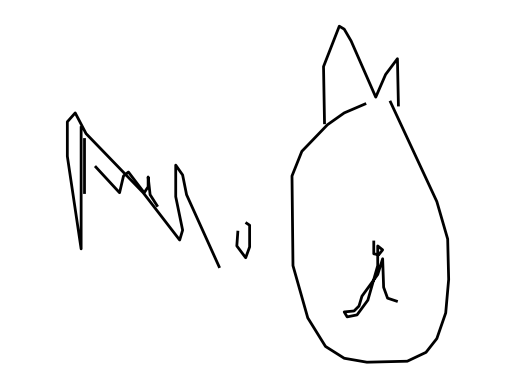

In [15]:
visualize_sequence(dataset_train[1][0])


x: min=-476.0, max=125.0
y: min=-173.0, max=329.0


<Axes: >

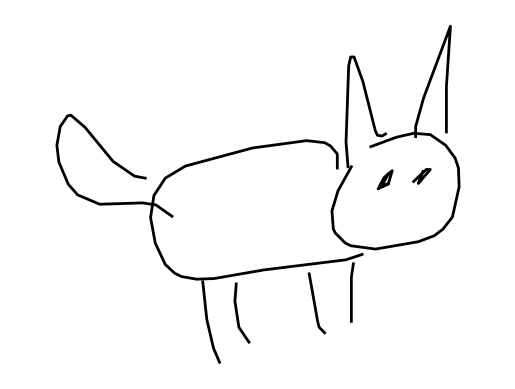

In [16]:
visualize_sequence(dataset_val[0][0])

x: min=-144.0, max=69.0
y: min=-94.0, max=192.0


<Axes: >

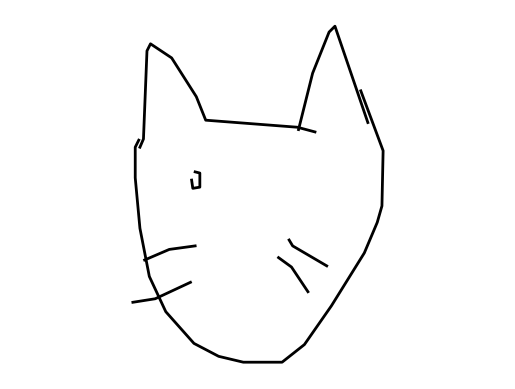

In [17]:
visualize_sequence(dataset_test_pre[2][0])

x: min=-195.18896484375, max=96.21969604492188
y: min=-122.96055603027344, max=66.22369384765625


<Axes: >

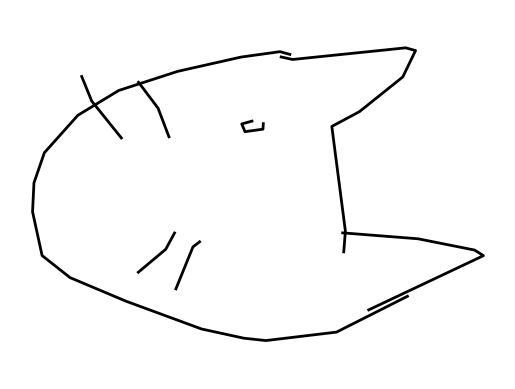

In [18]:
visualize_sequence(dataset_test[2][0])


In [19]:
stacked_data = torch.stack([dataset_train[i][0] for i in range(10)])

preprocessed_data = preprocess_module(stacked_data)

x: min=-127.5137939453125, max=125.05982971191406
y: min=-128.0, max=94.55194091796875


<Axes: title={'center': 'Preprocessed Sequence'}>

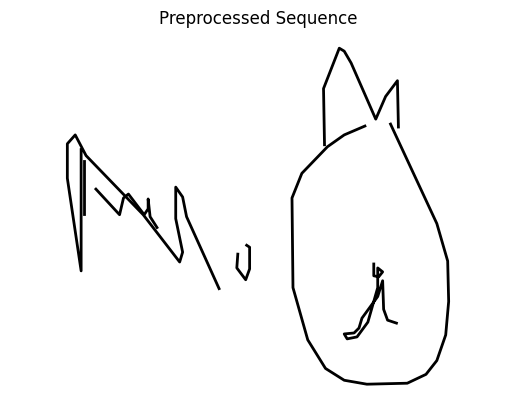

In [20]:
visualize_sequence(preprocessed_data[1],
                   title="Preprocessed Sequence")

x: min=-328.0, max=59.0
y: min=-78.0, max=263.0


<Axes: title={'center': 'Preprocessed Sequence'}>

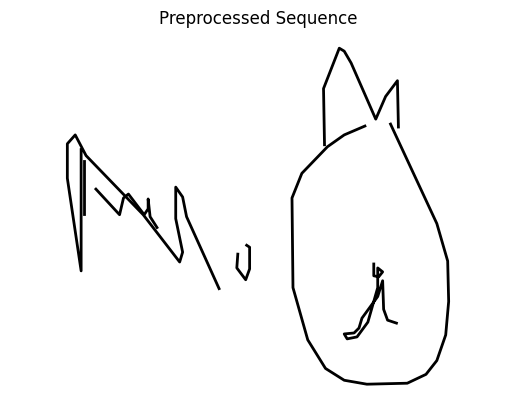

In [21]:
visualize_sequence(stacked_data[1],
                   title="Preprocessed Sequence")

In [22]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,
                                           persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,
                                         persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,
                                          persistent_workers=True)

dataset_val_transformed = AffineTransformDataset(dataset_val, sampler, return_transformation=False,
                                                 batch_size=batch_size)

val_loader_transformed = torch.utils.data.DataLoader(dataset_val_transformed, batch_size=batch_size, shuffle=False,
                                                     num_workers=4, persistent_workers=True)

In [23]:

import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes,preprocess=None):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        self.preprocess = preprocess or nn.Identity()  # Default to identity if no preprocessing is provided

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        with torch.no_grad():
            x = self.preprocess(x)

        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

from dataset.quickdraw import NormalizeToRangeBatched
preprocess_module = NormalizeToRangeBatched().to(device)

from pytorch_lightning.callbacks import ModelCheckpoint

modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric2.pth")
import pytorch_lightning as pl
import os

model_path2 = modelpath

model2 = BiLSTMClassifier(input_size=3, hidden_size=512, num_layers=3, num_classes=10,preprocess=preprocess_module).to(device)



# pick one model:
dataset = "quickdraw"


In [24]:
torch.set_float32_matmul_precision('medium')

In [56]:
from pytorch_lightning.callbacks import ModelCheckpoint

modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric2.pth")
import pytorch_lightning as pl
import os

model_path2 = modelpath

model2 = BiLSTMClassifier(input_size=3, hidden_size=512, num_layers=3, num_classes=10,preprocess=preprocess_module).to(device)

# Check if model is already trained
if os.path.exists(model_path2):
    print(f"Loading model from {model_path2}")
    model2.load_state_dict(torch.load(model_path2))
else:
    print(f"Training model and will save to {model_path2}")
    # LightningModule wrapper
    lightning_model = Classifier(
        model2,
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # Callbacks
    progress_bar     = MyProgressBar()
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True,
        dirpath=os.path.join(os.getcwd(), "model"),
        filename=f"{dataset}_val_acc_best"
    )

    # Trainer
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar, checkpoint_callback],
    )

    # Train
    trainer.fit(lightning_model, train_loader_transformed, val_loader_transformed)

    # 1) Reload LightningModule from best ckpt
    best_ckpt = checkpoint_callback.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    lightning_model = Classifier.load_from_checkpoint(
        best_ckpt,
        model=model2,  # supply same nn.Sequential structure
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # 2) Extract & save raw nn.Sequential weights
    model2.load_state_dict(lightning_model.model.state_dict())
    torch.save(model2.state_dict(), model_path2)
    print(f"Best model saved to {model_path2}")

with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

model2 = None
torch.cuda.empty_cache()


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | BiLSTMClassifier | 14.7 M | train
---------------------------------------------------
14.7 M    Trainable params
0         Non-trainable params
14.7 M    Total params
58.909    Total estimated model params size (MB)
3         Modules in train mode
1         Modules in eval mode


Training model and will save to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\quickdraw_metric2.pth
Epoch 0: 100%|██████████| 274/274 [00:45<00:00,  5.98it/s, v_num=410, train_loss=2.300, val_loss=2.300, val_acc=0.100]

Epoch 0, global step 274: 'val_acc' reached 0.10000 (best 0.10000), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\comparision_metrics\\model\\quickdraw_val_acc_best.ckpt' as top 1


Epoch 1: 100%|██████████| 274/274 [00:42<00:00,  6.50it/s, v_num=410, train_loss=2.300, val_loss=2.300, val_acc=0.100]

Epoch 1, global step 548: 'val_acc' reached 0.10010 (best 0.10010), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\comparision_metrics\\model\\quickdraw_val_acc_best.ckpt' as top 1


...

Epoch 28: 100%|██████████| 274/274 [00:40<00:00,  6.77it/s, v_num=410, train_loss=0.426, val_loss=1.930, val_acc=0.559]

Epoch 28, global step 7946: 'val_acc' was not in top 1


Epoch 29: 100%|██████████| 274/274 [00:40<00:00,  6.77it/s, v_num=410, train_loss=0.283, val_loss=1.920, val_acc=0.569]

Epoch 29, global step 8220: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 274/274 [00:40<00:00,  6.77it/s, v_num=410, train_loss=0.283, val_loss=1.920, val_acc=0.569]
Best Lightning checkpoint: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\quickdraw_val_acc_best.ckpt
Best model saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\quickdraw_metric2.pth
Mean accuracy on the transformed test set: 0.5758.


In [25]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model = BiLSTMClassifier(input_size=3, hidden_size=512, num_layers=3, num_classes=10,preprocess=preprocess_module).to(device)

# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class=torch.optim.AdamW, optimizer_params={"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader, val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")



Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\quickdraw_metric.pth


In [26]:
model.eval().cuda()

BiLSTMClassifier(
  (lstm): LSTM(3, 512, num_layers=3, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=1024, out_features=10, bias=True)
  (preprocess): NormalizeToRangeBatched()
)

In [27]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')


Mean accuracy on the val set: 0.7536.


In [28]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.3231.


In [29]:
list(model.named_modules())

[('',
  BiLSTMClassifier(
    (lstm): LSTM(3, 512, num_layers=3, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=10, bias=True)
    (preprocess): NormalizeToRangeBatched()
  )),
 ('lstm', LSTM(3, 512, num_layers=3, batch_first=True, bidirectional=True)),
 ('fc', Linear(in_features=1024, out_features=10, bias=True)),
 ('preprocess', NormalizeToRangeBatched())]

In [30]:
from confidence.utils import ModelInputWrapper, ModelOutputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'fc',flatten=True).eval()

In [31]:
filter_correct = True  # Set to False to include all samples

embeddings = []
images = []
classes = []
logits = []

for data, target in train_loader:
    data_cuda = data.cuda()
    emb_batch, logit_batch = dual_ouput_model(data_cuda)
    pred_batch = logit_batch.argmax(dim=-1).cpu().numpy()
    target_np = target.numpy()

    if filter_correct:
        mask = pred_batch == target_np
        emb_np = emb_batch.detach().cpu().numpy()[mask]
        logit_np = logit_batch.detach().cpu().numpy()[mask]
        img_np = data.numpy()[mask]
        class_np = target_np[mask]
    else:
        emb_np = emb_batch.detach().cpu().numpy()
        logit_np = logit_batch.detach().cpu().numpy()
        img_np = data.numpy()
        class_np = target_np

    embeddings.append(emb_np)
    logits.append(logit_np)
    images.append(img_np)
    classes.append(class_np)

embeddings = np.vstack(embeddings)
logits     = np.vstack(logits)
images     = np.vstack(images)
classes    = np.hstack(classes)

# randomly sample 5000 entries
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings_sampled = embeddings[indices]
    logits_sampled     = logits[indices]
    images_sampled     = images[indices]
    classes_sampled    = classes[indices]
else:
    embeddings_sampled = embeddings
    logits_sampled     = logits
    images_sampled     = images
    classes_sampled    = classes

In [32]:
#set rnn layer to train
#model.lstm.train()

In [33]:
import search.shgo
import importlib

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk", initial_samples=100, local_runs=2, local_max_steps=5)
di_no_grad = search.shgo.SHGO(selection_method="topk", local_max_steps=0, initial_samples=100)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=2, shuffle=False, num_workers=4,
                                          persistent_workers=True)
torch.cuda.empty_cache()


def evaluate_conf(model, di, problem, test_loader, max_batch_override=128,max_eval_steps=None):

    if max_batch_override is not None:
        problem.max_batch_size = max_batch_override
    with torch.no_grad():
        test_acc_sim = 0
        counter = 0
        for data, target in tqdm.tqdm(test_loader):
            data, target = data.cuda(), target.cuda()
            with torch.enable_grad():
                res = di.optimize(problem, data.cuda(), y=target.cuda())
                res = list(res)
            #torch.cuda.empty_cache()
            res[0] = res[0].detach()  # Detach the result to avoid gradients
            res[1] = res[1].detach()  # Detach the result to avoid gradients
            # Apply the transformation and get predictions
            x_transformed2 = problem.transform(data.cuda(), res[0])
            logits = model(x_transformed2)
            output = logits.argmax(dim=-1)
            test_acc_sim += output.eq(target).sum().cpu().detach().item()
            counter += output.shape[0]
            if max_eval_steps is not None and counter >= max_eval_steps:
                break

    test_acc_sim /= counter
    return test_acc_sim




In [36]:
import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

conf_mod_nn_pytorch = SinglePassConfidence(model, EnergyConfidence())
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch, transform_seq, consolidate_method="consolidate_simple")
evaluate_conf(model, di_no_grad, problem_nn_pytorch, test_loader,max_eval_steps=100)

  0%|          | 0/40 [00:13<?, ?it/s]


0.41796875

In [37]:
import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=True,b=0.0,scale_final="softplus")
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")
evaluate_conf(model,di_no_grad,problem_nn_pytorch,test_loader,max_eval_steps=100)


  0%|          | 0/40 [00:10<?, ?it/s]


0.41015625

In [38]:
import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings).cpu())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=True,b=0.02,scale_final="softplus")
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")
evaluate_conf(model,di_no_grad,problem_nn_pytorch,test_loader,max_eval_steps=100)


  0%|          | 0/40 [00:11<?, ?it/s]


0.48046875

In [43]:
import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings).cpu(),torch.tensor(classes).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=True,b=0.02)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")
evaluate_conf(model,di_no_grad,problem_nn_pytorch,test_loader,max_eval_steps=100)


  0%|          | 0/40 [00:11<?, ?it/s]


0.45703125

In [64]:
import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="euclidean",k=3)
nn_pytorch.fit(torch.tensor(embeddings).cpu(),torch.tensor(classes).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=True,b=0.0001)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")
evaluate_conf(model,di_no_grad,problem_nn_pytorch,test_loader,max_eval_steps=100)




  0%|          | 0/40 [00:11<?, ?it/s]


0.5390625

In [46]:
embeddings.shape

(64416, 1024)

In [57]:
import confidence
from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
import importlib
importlib.reload(confidence.unsupervised.classic.VIM)
gmm_conf = ViMTorchConfidence(model.eval(),n_dim=256,use_energy=True)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
print(gmm_conf.alpha)
conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
evaluate_conf(model,di_no_grad,problem_gmm_conf,test_loader)

18.978578567504883
fitted




  0%|          | 0/40 [00:00<?, ?it/s]

  2%|▎         | 1/40 [00:10<06:32, 10.06s/it]

  5%|▌         | 2/40 [00:20<06:20, 10.02s/it]

  8%|▊         | 3/40 [00:30<06:15, 10.15s/it]

 10%|█         | 4/40 [00:40<06:00, 10.01s/it]

 12%|█▎        | 5/40 [00:49<05:47,  9.93s/it]

 15%|█▌        | 6/40 [00:59<05:35,  9.87s/it]

 18%|█▊        | 7/40 [01:09<05:24,  9.85s/it]

 20%|██        | 8/40 [01:19<05:14,  9.82s/it]

 22%|██▎       | 9/40 [01:29<05:04,  9.83s/it]

 25%|██▌       | 10/40 [01:38<04:53,  9.80s/it]

 28%|██▊       | 11/40 [01:48<04:44,  9.80s/it]

 30%|███       | 12/40 [01:58<04:34,  9.80s/it]

 32%|███▎      | 13/40 [02:08<04:24,  9.81s/it]

 35%|███▌      | 14/40 [02:18<04:16,  9.86s/it]

 38%|███▊      | 15/40 [02:28<04:06,  9.84s/it]

 40%|████      | 16/40 [02:38<03:58,  9.94s/it]

 42%|████▎     | 17/40 [02:48<03:50, 10.04s/it]

 45%|████▌     | 18/40 [02:58<03:39,  9.98s/it]

 48%|████▊     | 19/40 [03:08<03:27,  9.89s/it]

 50%|█████     | 20/40 [03:17<03:16,

0.5214

In [48]:
class backbone_wrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        with torch.no_grad():
            x = self.model.preprocess(x)
        return self.model.lstm(x)[0][:, -1, :]

In [49]:
backbone = backbone_wrapper(model).cuda()

In [50]:
head = model.fc

In [51]:
#calculate 99 percent quntiale of embeddings entries per dim
quantiles = np.quantile(embeddings_sampled, 0.99, axis=0)

In [54]:
quantiles.max()

0.9999955892562866

In [62]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(backbone,head,threshold=0.7)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

evaluate_conf(model,di_no_grad,problem_gmm_conf,test_loader,max_eval_steps=100)



  0%|          | 0/40 [00:10<?, ?it/s]


0.39453125